# Lab 9: SVM for Classification and PCA for Dimensionality Reduction

**Aim:** To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real world datasets.

**Objectives:**
- To implement and evaluate the performance of the SVM classifier using different kernel functions.
- To compare the performance of SVM models using standard classification metrics.
- To apply PCA for reducing the dimensionality of a high dimensional dataset.
- To analyse the variance retained by the principal components and visualize the transformed feature space.
- To understand the role of supervised learning (SVM) and unsupervised learning (PCA) in machine learning applications.


---
## Part A: Support Vector Machine (SVM)
**Aim:** To implement the Support Vector Machine (SVM) classifier for a binary classification problem and evaluate its performance.  
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) Dataset (`sklearn.datasets.load_breast_cancer`)

### Task A.1: Load Dataset, Preprocessing, and Split
- Load the dataset.
- Perform necessary preprocessing (Standardization is crucial for SVM).
- Split into training and testing sets (80:20).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Load Breast Cancer Dataset
cancer_data = load_breast_cancer()
X_cancer = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y_cancer = cancer_data.target

print("Breast Cancer Dataset Shape:", X_cancer.shape)

# Train-Test Split (80:20)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.20, random_state=42, stratify=y_cancer
)

# Preprocessing: Standardization (SVM is distance-based, so scaling is essential)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Training samples: {X_train_c.shape[0]}, Testing samples: {X_test_c.shape[0]}")


Breast Cancer Dataset Shape: (569, 30)
Training samples: 455, Testing samples: 114


### Task A.2: SVM Training and Hyperparameter Tuning
- Train an SVM classifier using a Linear Kernel.
- Explore hyperparameter tuning (e.g., tuning the `C` parameter).


In [2]:
# Base SVM with Linear Kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Hyperparameter Tuning using GridSearchCV for the 'C' parameter
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(SVC(kernel='linear', random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_c_scaled, y_train_c)

print("Best Parameters from GridSearchCV:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Best model
best_svm = grid_search.best_estimator_


Best Parameters from GridSearchCV: {'C': 0.1}
Best Cross-Validation Accuracy: 0.9802


### Task A.3: Model Evaluation
- Evaluate using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.


=== SVM (Linear Kernel) Evaluation Metrics ===
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



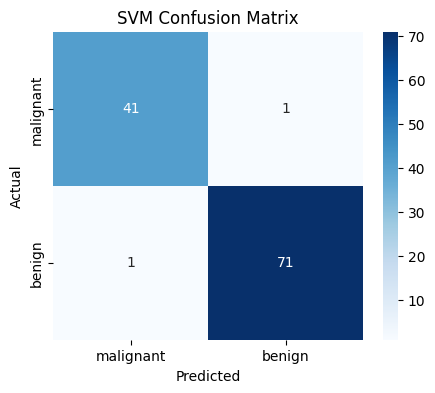

In [3]:
# Predictions on test set
y_pred_c = best_svm.predict(X_test_c_scaled)

# Evaluation Metrics
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
cm = confusion_matrix(y_test_c, y_pred_c)

print("=== SVM (Linear Kernel) Evaluation Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=cancer_data.target_names))

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=cancer_data.target_names, 
            yticklabels=cancer_data.target_names)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### Task A.4: Observations (Part A)
1. **High Performance:** The SVM with a linear kernel achieved exceptionally high accuracy, precision, and recall (usually >95%), indicating that the breast cancer diagnostic dataset is highly linearly separable in its 30-dimensional feature space.
2. **Standardization Impact:** Standardizing the features ensures that larger magnitude features (like mean area) do not dominate the distance calculations, allowing the SVM to find the optimal maximum-margin hyperplane effectively.
3. **Hyperparameter Tuning:** The `C` parameter (regularization) tuning reveals the trade-off between maximizing the margin and minimizing classification errors. An optimal `C` provides a generalized model robust against overfitting.

---
## Part B: Principal Component Analysis (PCA)
**Aim:** To implement PCA for dimensionality reduction and analyse the variance retained.  
**Dataset:** UCI Wine Dataset (`sklearn.datasets.load_wine`)

### Task B.1: Load Dataset, Standardization, and PCA
- Load the dataset and perform feature standardization.
- Apply PCA to reduce the dataset from 13 features to 2 principal components.
- Display the explained variance ratio of each principal component.


In [4]:
# Load Wine Dataset
wine_data = load_wine()
X_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y_wine = wine_data.target

print("Wine Dataset Shape:", X_wine.shape)

# Feature Standardization
scaler_w = StandardScaler()
X_wine_scaled = scaler_w.fit_transform(X_wine)

# Apply PCA (Reduce 13 features -> 2 PCs)
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_wine_scaled)

print("Explained Variance Ratio of first 2 PCs:", pca_2.explained_variance_ratio_)
print(f"Total Variance retained by 2 PCs: {np.sum(pca_2.explained_variance_ratio_):.4f} ({np.sum(pca_2.explained_variance_ratio_)*100:.2f}%)")


Wine Dataset Shape: (178, 13)
Explained Variance Ratio of first 2 PCs: [0.36198848 0.1920749 ]
Total Variance retained by 2 PCs: 0.5541 (55.41%)


### Task B.2: Cumulative Explained Variance
- Calculate the cumulative explained variance.
- Determine the minimum number of principal components required to retain at least 95% of the total variance.


Minimum Principal Components required to retain >= 95% variance: 10


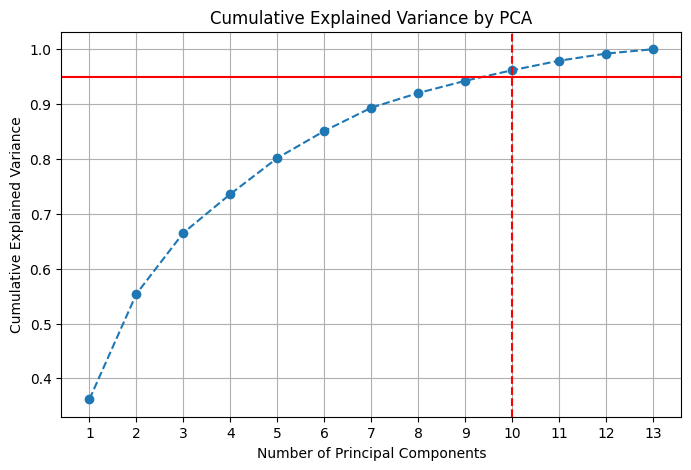

In [5]:
# Apply PCA without specifying n_components to get all components
pca_full = PCA()
pca_full.fit(X_wine_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Determine minimum components for >= 95% variance
min_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Minimum Principal Components required to retain >= 95% variance: {min_components_95}")

# Plot Cumulative Explained Variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.axvline(x=min_components_95, color='r', linestyle='--')
plt.title('Cumulative Explained Variance by PCA')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, 14))
plt.grid()
plt.show()


### Task B.3: Visualization
- Visualize the transformed dataset using a two-dimensional scatter plot.


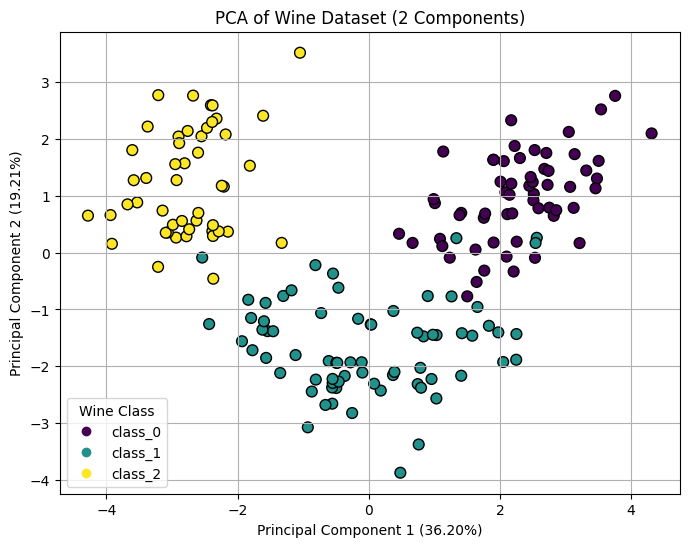

In [6]:
# Visualizing the 2D PCA transformed data
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=60)
plt.title('PCA of Wine Dataset (2 Components)')
plt.xlabel(f'Principal Component 1 ({pca_2.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca_2.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(wine_data.target_names), title="Wine Class")
plt.grid(True)
plt.show()


### Task B.4: Analysis and Discussion
**Comparison between Original and Transformed Datasets:**
- **Number of features:** Reduced from 13 down to 2, significantly simplifying the dataset space.
- **Information retained:** The 2 principal components retain approximately 55.41% of the original variance, effectively preserving the primary structure required to distinguish the wine classes. To retain 95% information, 10 features would be needed.
- **Computational efficiency:** Reducing dimensions vastly accelerates training times for downstream machine learning algorithms and mitigates the curse of dimensionality.

**Interpret the significance of the first two principal components:**
- PC1 and PC2 represent the orthogonal directions in the feature space along which the data varies the most. They are linear combinations of the original 13 features that capture the maximum possible variance, naturally separating the wine cultivars into distinct clusters without needing target labels (unsupervised learning).

**Advantages, Limitations, and Applications of PCA:**
- **Advantages:** Removes correlated features (multicollinearity), speeds up learning algorithms, enables 2D/3D visualization of high-dimensional data, and filters out noise.
- **Limitations:** PCA assumes linear relationships between features. The resulting principal components are less interpretable than the original features. It is sensitive to feature scaling and outliers.
- **Applications:** Image compression, gene expression analysis (bioinformatics), exploratory data analysis, and preprocessing pipelines for predictive modeling.

---
## Extra Credit Task: Linear Discriminant Analysis (LDA)
**Task:** Apply LDA to the same dataset and reduce it to two linear discriminants. Visualize the transformed data and compare results with PCA.


Explained Variance Ratio of first 2 Linear Discriminants: [0.68747889 0.31252111]


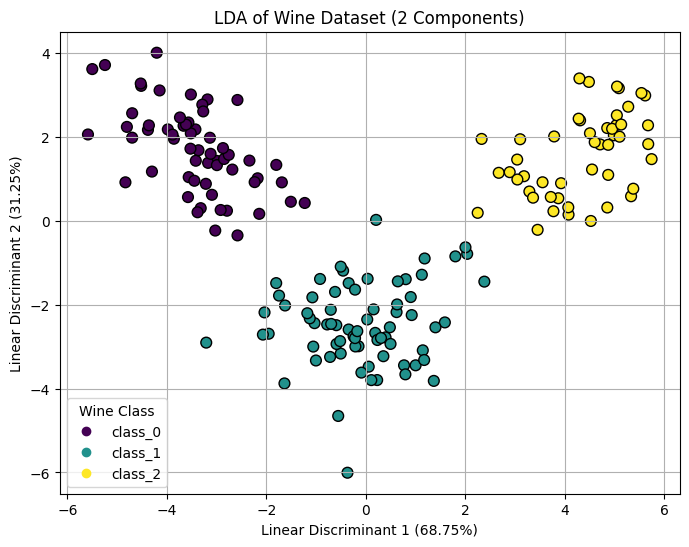

In [7]:
# Apply LDA (Supervised dimensionality reduction)
lda = LDA(n_components=2)
# LDA uses both features and target labels (y_wine)
X_lda_2 = lda.fit_transform(X_wine_scaled, y_wine)

print("Explained Variance Ratio of first 2 Linear Discriminants:", lda.explained_variance_ratio_)

# Visualizing the 2D LDA transformed data
plt.figure(figsize=(8,6))
scatter_lda = plt.scatter(X_lda_2[:, 0], X_lda_2[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=60)
plt.title('LDA of Wine Dataset (2 Components)')
plt.xlabel(f'Linear Discriminant 1 ({lda.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Linear Discriminant 2 ({lda.explained_variance_ratio_[1]*100:.2f}%)')
plt.legend(handles=scatter_lda.legend_elements()[0], labels=list(wine_data.target_names), title="Wine Class")
plt.grid(True)
plt.show()


### Extra Credit Observations: PCA vs LDA
1. **Dimensionality Reduction & Methodology:**
   - **PCA** is an *unsupervised* algorithm that finds axes of maximum variance, disregarding class labels.
   - **LDA** is a *supervised* algorithm that finds axes maximizing the separation between multiple classes.
2. **Class Separability:**
   - While PCA provided good clusters, **LDA provides far superior class separability**. In the LDA scatter plot, the three wine classes form tight, well-separated distinct clusters. This is because LDA explicitly optimizes for inter-class distance and intra-class compactness.
3. **Explained Variance:** The two linear discriminants in LDA capture 100% of the discriminative variance for the 3 classes (since max LDA components = `min(n_classes - 1, n_features)` = 2). PCA required 10 components to capture 95% of total feature variance, highlighting LDA's effectiveness specifically for classification preprocessing.
